# Decision tree classifier

This notebook:

1. selects peak detectors from `algorithms.py` and/or trained `AlgorithmGraph` artifacts,
2. builds or loads the classifier input dataframe,
3. trains and evaluates a decision tree.

In [43]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


# The notebook works when Jupyter is started either in the repository root
# or directly inside the classifier directory.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "detector_engine").exists():
    if (REPO_ROOT.parent / "detector_engine").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError(
            "Could not find detector_engine. Start Jupyter from the repository "
            "root or from the classifier directory."
        )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from classifier.input_to_classifier import build_classifier_input
from detector_engine import load_best_graph

try:
    import algorithms
except ModuleNotFoundError:
    # Compatibility with the previous capitalized filename.
    import Algorithms as algorithms

In [44]:
QRS_ANNOTATIONS = {
    "N", "L", "R", "V", "/", "A", "f", "F",
    "a", "J", "S", "e", "j", "E", "Q",
}

GROUPING_SCHEMES = {
    "current": {
        "N": {"N"},
        "A": {"A"},
        "V": {"V"},
        "R": {"R"},
        "L": {"L"},
        "/": {"/"},
        "Other": QRS_ANNOTATIONS - {"N", "A", "V", 'R', 'L', '/'},
    },

    "aami": {
        "N": {"N", "L", "R", "e", "j"},
        "S": {"A", "a", "J", "S"},
        "V": {"V", "E"},
        "F": {"F"},
        "Q": {"/", "f", "Q"},
    },
}


def group_annotations(annotation_series, scheme):
    if scheme not in GROUPING_SCHEMES:
        raise ValueError(
            f"Unknown grouping scheme: {scheme!r}. "
            f"Available schemes: {list(GROUPING_SCHEMES)}"
        )

    groups = GROUPING_SCHEMES[scheme]

    label_to_group = {
        annotation: group_name
        for group_name, annotations in groups.items()
        for annotation in annotations
    }

    # These are generated by ClassifierInputBuilder,
    # rather than originating from the ECG annotation file.
    label_to_group["FP"] = "FP"
    label_to_group["AMB"] = "AMB"

    annotations = annotation_series.astype(str)
    grouped = annotations.map(label_to_group)

    unknown = sorted(annotations[grouped.isna()].unique())

    if unknown:
        raise ValueError(
            f"Annotations not covered by scheme {scheme!r}: {unknown}"
        )

    return grouped

In [45]:
LABEL_GROUPING = "current"
# LABEL_GROUPING = "aami"

In [46]:
DATA_PATH = REPO_ROOT / "dataset" / "train.pkl"
CLASSIFIER_INPUT_PATH = REPO_ROOT / "classifier" / "classifier_input.pickle"
REFERENCE_DETECTOR = "alg1"
MATCH_WINDOW = 50

BASE_DETECTORS = {
    "alg1": algorithms.alg1_spanish,
    "alg2": algorithms.alg4_polish_20210222,
    "alg3": algorithms.alg3_iranian,
    "alg4": algorithms.alg5_pan_tompkins,
    "alg5": algorithms.Alg5_Turkish,
}

## Configuration

In [47]:
from pathlib import Path

import pandas as pd
from IPython.display import display



source_df = pd.read_pickle(DATA_PATH)

classifier_df = build_classifier_input(
    dataset=source_df,
    detectors=BASE_DETECTORS,
    reference_detector=REFERENCE_DETECTOR,
    window=MATCH_WINDOW,
    output_path=CLASSIFIER_INPUT_PATH,
)

print(f"Created classifier input with {len(classifier_df):,} rows")
print(f"Saved to: {CLASSIFIER_INPUT_PATH}")

display(classifier_df.head())
display(classifier_df["annotation"].value_counts())

Created classifier input with 55,686 rows
Saved to: /Users/jeremiasz/code/ekg-evo/new/classifier/classifier_input.pickle


,record,reference_peak,alg2,alg3,alg4,alg5,annotation
0,232,31,-100,-100,-100,-100,FP
1,232,188,-100,-100,35,-100,FP
2,232,430,-100,-100,18,-100,FP
3,232,506,-13,-8,-100,-100,R
4,232,751,-12,-100,25,32,A


annotation
N     35801
FP     4729
L      4607
R      4068
V      2815
/      1938
A      1510
J        81
f        51
F        43
a        28
Q         8
j         6
E         1
Name: count, dtype: int64

In [48]:
classifier_df['annotation'].unique()

<StringArray>
['FP', 'R', 'A', 'j', 'N', 'V', 'Q', 'J', '/', 'L', 'F', 'a', 'E', 'f']
Length: 14, dtype: str

In [49]:
classifier_df = pd.read_pickle(CLASSIFIER_INPUT_PATH)
classifier_df

,record,reference_peak,alg2,alg3,alg4,alg5,annotation
0,232,31,-100,-100,-100,-100,FP
1,232,188,-100,-100,35,-100,FP
2,232,430,-100,-100,18,-100,FP
3,232,506,-13,-8,-100,-100,R
4,232,751,-12,-100,25,32,A
...,...,...,...,...,...,...,...
55681,114,648722,-12,-8,18,21,N
55682,114,649005,-11,-8,2,23,N
55683,114,649273,-11,-7,20,26,N
55684,114,649536,-11,-8,19,24,N


## Build or load classifier input

In [50]:
FULL_SEARCH_ROOT = REPO_ROOT / "Full_search_artifacts"

GRAPH_TRIALS = {}

trial_directories = sorted(
    (
        trial_dir
        for configuration_dir in FULL_SEARCH_ROOT.iterdir()
        if configuration_dir.is_dir()
        for trial_dir in configuration_dir.glob("trial_*")
        if trial_dir.is_dir()
    ),
    key=lambda path: (
        path.parent.name,
        int(path.name.removeprefix("trial_")),
    ),
)

for trial_directory in trial_directories:
    configuration_name = trial_directory.parent.name.lower()
    trial_number = int(trial_directory.name.removeprefix("trial_"))

    detector_name = (
        f"evolved_{configuration_name}_trial_{trial_number}"
    )

    GRAPH_TRIALS[detector_name] = trial_directory


print(f"Discovered {len(GRAPH_TRIALS)} evolved algorithms")

for detector_name, trial_directory in GRAPH_TRIALS.items():
    print(f"{detector_name}: {trial_directory}")

Discovered 36 evolved algorithms
evolved_early_na_trial_0: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_000
evolved_early_na_trial_1: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_001
evolved_early_na_trial_2: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_002
evolved_early_na_trial_3: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_003
evolved_early_na_trial_4: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_004
evolved_early_na_trial_5: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_NA/trial_005
evolved_early_others_trial_0: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_OTHERS/trial_000
evolved_early_others_trial_1: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_OTHERS/trial_001
evolved_early_others_trial_2: /Users/jeremiasz/code/ekg-evo/new/Full_search_artifacts/EARLY_OTHERS/trial_002
evolved_early_others_trial_3: /Use

In [51]:
existing_columns = set(classifier_df.columns)

graphs_already_present = [
    detector_name
    for detector_name in GRAPH_TRIALS
    if detector_name in existing_columns
]

graphs_to_add = [
    detector_name
    for detector_name in GRAPH_TRIALS
    if detector_name not in existing_columns
]

print("Already present evolved columns:")
for name in graphs_already_present:
    print(f"  {name}")

print("\nEvolved columns to add:")
for name in graphs_to_add:
    print(f"  {name}")

print(
    f"\nAlready present: {len(graphs_already_present)}, "
    f"to add: {len(graphs_to_add)}"
)

Already present evolved columns:

Evolved columns to add:
  evolved_early_na_trial_0
  evolved_early_na_trial_1
  evolved_early_na_trial_2
  evolved_early_na_trial_3
  evolved_early_na_trial_4
  evolved_early_na_trial_5
  evolved_early_others_trial_0
  evolved_early_others_trial_1
  evolved_early_others_trial_2
  evolved_early_others_trial_3
  evolved_early_others_trial_4
  evolved_early_others_trial_5
  evolved_early_v_trial_0
  evolved_early_v_trial_1
  evolved_early_v_trial_2
  evolved_early_v_trial_3
  evolved_early_v_trial_4
  evolved_early_v_trial_5
  evolved_late_na_trial_0
  evolved_late_na_trial_1
  evolved_late_na_trial_2
  evolved_late_na_trial_3
  evolved_late_na_trial_4
  evolved_late_na_trial_5
  evolved_late_others_trial_0
  evolved_late_others_trial_1
  evolved_late_others_trial_2
  evolved_late_others_trial_3
  evolved_late_others_trial_4
  evolved_late_others_trial_5
  evolved_late_v_trial_0
  evolved_late_v_trial_1
  evolved_late_v_trial_2
  evolved_late_v_trial_3
  

In [52]:
# Ordinary detector functions can also be added here.
NEW_DETECTORS = {
    # "alg6": algorithms.some_new_algorithm,
}

GRAPH_SETTINGS = {
    # Optional detector-specific settings:
    #
    # "evolved_early_na_trial_0": {
    #     "threshold_quantile": 0.98,
    #     "min_distance": 90,
    # },
}


source_df = pd.read_pickle(DATA_PATH)
classifier_df = pd.read_pickle(CLASSIFIER_INPUT_PATH)

# Find which discovered graph columns are already present.
existing_graph_names = [
    detector_name
    for detector_name in GRAPH_TRIALS
    if detector_name in classifier_df.columns
]

missing_graph_names = [
    detector_name
    for detector_name in GRAPH_TRIALS
    if detector_name not in classifier_df.columns
]

print(f"Discovered graphs: {len(GRAPH_TRIALS)}")
print(f"Already present: {len(existing_graph_names)}")
print(f"Need to add: {len(missing_graph_names)}")

if existing_graph_names:
    print("\nAlready present:")
    for detector_name in existing_graph_names:
        print(f"  {detector_name}")

if missing_graph_names:
    print("\nWill be added:")
    for detector_name in missing_graph_names:
        print(f"  {detector_name}")


# Load only graphs whose columns are not already in classifier_df.
for detector_name in missing_graph_names:
    trial_directory = GRAPH_TRIALS[detector_name]
    _, graph = load_best_graph(trial_directory)
    NEW_DETECTORS[detector_name] = graph


if not NEW_DETECTORS:
    print("\nNo computation needed. All discovered graph columns already exist.")

else:
    print(f"\nComputing {len(NEW_DETECTORS)} new detector columns...")

    # Rows must be generated using the same reference detector as before.
    update_detectors = {
        REFERENCE_DETECTOR: BASE_DETECTORS[REFERENCE_DETECTOR],
        **NEW_DETECTORS,
    }

    update_df = build_classifier_input(
        dataset=source_df,
        detectors=update_detectors,
        reference_detector=REFERENCE_DETECTOR,
        window=MATCH_WINDOW,
        graph_threshold_quantile=0.97,
        graph_min_distance=80,
        graph_settings=GRAPH_SETTINGS,
    )

    new_feature_names = list(NEW_DETECTORS)
    key_columns = ["record", "reference_peak"]

    # Keep merge keys as integers in both dataframes.
    for column in key_columns:
        classifier_df[column] = pd.to_numeric(
            classifier_df[column],
            errors="raise",
        ).astype("int64")

        update_df[column] = pd.to_numeric(
            update_df[column],
            errors="raise",
        ).astype("int64")

    # Verify that the reference detector generated exactly the same rows.
    base_keys = pd.MultiIndex.from_frame(classifier_df[key_columns])
    update_keys = pd.MultiIndex.from_frame(update_df[key_columns])

    missing_keys = base_keys.difference(update_keys)
    extra_keys = update_keys.difference(base_keys)

    if len(missing_keys) > 0 or len(extra_keys) > 0:
        raise RuntimeError(
            "The reference-detector rows differ from the saved dataframe. "
            f"Missing rows: {len(missing_keys)}, "
            f"extra rows: {len(extra_keys)}. "
            "Rebuild the complete classifier dataframe instead."
        )

    columns_to_merge = [
        *key_columns,
        *new_feature_names,
        "annotation",
    ]

    update_subset = update_df[columns_to_merge].rename(
        columns={"annotation": "updated_annotation"}
    )

    classifier_df = classifier_df.merge(
        update_subset,
        on=key_columns,
        how="left",
        validate="one_to_one",
        sort=False,
    )

    # Verify that annotations have not changed.
    annotation_mismatch = (
        classifier_df["annotation"].astype(str)
        != classifier_df["updated_annotation"].astype(str)
    )

    if annotation_mismatch.any():
        raise RuntimeError(
            f"Annotation mismatch in {annotation_mismatch.sum()} rows. "
            "Check MATCH_WINDOW and the source dataset."
        )

    if classifier_df[new_feature_names].isna().any().any():
        missing_counts = (
            classifier_df[new_feature_names]
            .isna()
            .sum()
        )
        missing_counts = missing_counts[missing_counts > 0]

        raise RuntimeError(
            "Some new detector columns contain missing values:\n"
            f"{missing_counts}"
        )

    classifier_df = classifier_df.drop(
        columns="updated_annotation"
    )

    # Preserve integer detector outputs.
    classifier_df[new_feature_names] = (
        classifier_df[new_feature_names]
        .astype(int)
    )

    classifier_df.to_pickle(CLASSIFIER_INPUT_PATH)

    print("\nUpdated columns:")
    for detector_name in new_feature_names:
        print(f"  {detector_name}")

    print(f"\nSaved to: {CLASSIFIER_INPUT_PATH}")

    display(classifier_df.head())
    display(classifier_df[new_feature_names].describe())

Discovered graphs: 36
Already present: 0
Need to add: 36

Will be added:
  evolved_early_na_trial_0
  evolved_early_na_trial_1
  evolved_early_na_trial_2
  evolved_early_na_trial_3
  evolved_early_na_trial_4
  evolved_early_na_trial_5
  evolved_early_others_trial_0
  evolved_early_others_trial_1
  evolved_early_others_trial_2
  evolved_early_others_trial_3
  evolved_early_others_trial_4
  evolved_early_others_trial_5
  evolved_early_v_trial_0
  evolved_early_v_trial_1
  evolved_early_v_trial_2
  evolved_early_v_trial_3
  evolved_early_v_trial_4
  evolved_early_v_trial_5
  evolved_late_na_trial_0
  evolved_late_na_trial_1
  evolved_late_na_trial_2
  evolved_late_na_trial_3
  evolved_late_na_trial_4
  evolved_late_na_trial_5
  evolved_late_others_trial_0
  evolved_late_others_trial_1
  evolved_late_others_trial_2
  evolved_late_others_trial_3
  evolved_late_others_trial_4
  evolved_late_others_trial_5
  evolved_late_v_trial_0
  evolved_late_v_trial_1
  evolved_late_v_trial_2
  evolved_la

,record,reference_peak,alg2,alg3,alg4,alg5,annotation,evolved_early_na_trial_0,evolved_early_na_trial_1,evolved_early_na_trial_2,...,evolved_late_others_trial_2,evolved_late_others_trial_3,evolved_late_others_trial_4,evolved_late_others_trial_5,evolved_late_v_trial_0,evolved_late_v_trial_1,evolved_late_v_trial_2,evolved_late_v_trial_3,evolved_late_v_trial_4,evolved_late_v_trial_5
0,232,31,-100,-100,-100,-100,FP,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
1,232,188,-100,-100,35,-100,FP,-100,-100,-100,...,-100,-100,-100,-100,-100,-100,-100,-100,-100,-100
2,232,430,-100,-100,18,-100,FP,-100,-100,-100,...,-100,-100,43,-100,-100,-100,-100,-100,-100,-100
3,232,506,-13,-8,-100,-100,R,-19,-16,-17,...,-21,-25,-33,-24,-18,-19,-18,-19,-19,-22
4,232,751,-12,-100,25,32,A,-18,-15,-17,...,-26,-25,-32,-24,-16,-19,-18,-19,-18,-22


,evolved_early_na_trial_0,evolved_early_na_trial_1,evolved_early_na_trial_2,evolved_early_na_trial_3,evolved_early_na_trial_4,evolved_early_na_trial_5,evolved_early_others_trial_0,evolved_early_others_trial_1,evolved_early_others_trial_2,evolved_early_others_trial_3,...,evolved_late_others_trial_2,evolved_late_others_trial_3,evolved_late_others_trial_4,evolved_late_others_trial_5,evolved_late_v_trial_0,evolved_late_v_trial_1,evolved_late_v_trial_2,evolved_late_v_trial_3,evolved_late_v_trial_4,evolved_late_v_trial_5
count,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,...,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000,55686.000000
mean,-16.323744,-16.360917,-15.767051,-14.758844,-7.323708,-8.339421,-10.453938,-13.382484,-13.199637,-9.311048,...,-18.059512,-19.562727,-32.666846,-4.947599,-28.888823,-26.333333,-25.793305,-25.418130,-26.202277,-28.145638
std,23.479679,26.996717,20.588441,26.624718,33.205754,34.751127,26.909074,29.555312,30.773815,29.203805,...,22.937550,23.758210,25.636406,33.157830,25.587881,24.660592,25.364398,25.138061,26.504302,27.307816
min,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,...,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000,-100.000000
25%,-20.000000,-18.000000,-19.000000,-17.000000,-22.000000,-16.000000,-8.000000,-9.000000,-8.000000,-4.000000,...,-25.000000,-25.000000,-33.000000,-23.000000,-25.000000,-20.000000,-19.000000,-21.000000,-19.000000,-23.000000
50%,-18.000000,-15.000000,-17.000000,-9.000000,-21.000000,-7.000000,-1.000000,-2.000000,0.000000,-1.000000,...,-15.000000,-18.000000,-24.000000,-15.000000,-23.000000,-19.000000,-18.000000,-19.000000,-18.000000,-19.000000
75%,-8.000000,-4.000000,-7.000000,-1.000000,28.000000,18.000000,0.000000,-1.000000,0.000000,1.000000,...,-10.000000,-15.000000,-21.000000,26.000000,-17.000000,-19.000000,-18.000000,-17.000000,-17.000000,-18.000000
max,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,...,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000


In [68]:
classifier_df = pd.read_pickle(CLASSIFIER_INPUT_PATH)

SELECTED_FEATURES = [
    # Existing algorithms
    "alg2",
    "alg3",
    "alg4",
    "alg5",

    # All automatically discovered evolved graphs
    # *GRAPH_TRIALS.keys(),
]

# SELECTED_FEATURES = ORDERED_FEATURE_LIST[:20]
SELECTED_FEATURES = ['evolved_early_na_trial_3', 'alg3', 'evolved_early_v_trial_0', 'evolved_early_v_trial_3', 'alg5', 'evolved_early_v_trial_2', 'evolved_early_others_trial_1']

if REFERENCE_DETECTOR in SELECTED_FEATURES:
    raise ValueError(
        "The reference detector cannot be used as a feature because "
        "its detections define the dataframe rows"
    )

missing_features = [
    feature
    for feature in SELECTED_FEATURES
    if feature not in classifier_df.columns
]

if missing_features:
    raise KeyError(
        f"These features are not present in classifier_input.pkl: "
        f"{missing_features}"
    )


# LABEL_GROUPING = "current"
# LABEL_GROUPING = "aami"

X = classifier_df[SELECTED_FEATURES].astype(int).copy()

y = group_annotations(
    classifier_df["annotation"],
    scheme=LABEL_GROUPING,
)

# Ambiguous matches are not reliable training targets.
ambiguous_mask = y == "AMB"

if ambiguous_mask.any():
    print("Removing ambiguous detections:", ambiguous_mask.sum())
    X = X.loc[~ambiguous_mask].copy()
    y = y.loc[~ambiguous_mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y,
)

print("Label grouping:", LABEL_GROUPING)
print("Features:", SELECTED_FEATURES)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
display(y.value_counts())

Label grouping: current
Features: ['evolved_early_na_trial_3', 'alg3', 'evolved_early_v_trial_0', 'evolved_early_v_trial_3', 'alg5', 'evolved_early_v_trial_2', 'evolved_early_others_trial_1']
Training rows: 38980
Test rows: 16706


annotation
N        35801
FP        4729
L         4607
R         4068
V         2815
/         1938
A         1510
Other      218
Name: count, dtype: int64

## Prepare labels and split the data

In [69]:
X = classifier_df[SELECTED_FEATURES].astype(int).copy()
y = classifier_df["annotation"].astype(str).copy()

y = group_annotations(
    classifier_df["annotation"],
    scheme=LABEL_GROUPING,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=0,
    stratify=y,
)

print("Features:", SELECTED_FEATURES)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
display(y.value_counts())

Features: ['evolved_early_na_trial_3', 'alg3', 'evolved_early_v_trial_0', 'evolved_early_v_trial_3', 'alg5', 'evolved_early_v_trial_2', 'evolved_early_others_trial_1']
Training rows: 38980
Test rows: 16706


annotation
N        35801
FP        4729
L         4607
R         4068
V         2815
/         1938
A         1510
Other      218
Name: count, dtype: int64

## Train and tune the decision tree

In [70]:
parameter_grid = {
    "criterion": ["entropy"],
    "max_depth": [15],
    # "min_samples_split": [2, 5, 10],
    # "min_samples_leaf": [1, 2, 5],
    "class_weight": ["balanced"],
    # "ccp_alpha": [0.0, 0.001, 0.01],
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0,
)

search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=0),
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=cross_validation,
    n_jobs=-1,
)

search.fit(X_train, y_train)
classifier = search.best_estimator_

train_predictions = classifier.predict(X_train)
test_predictions = classifier.predict(X_test)

print("Best parameters:", search.best_params_)
print(f"Best CV macro F1: {search.best_score_:.4f}")
print(f"Training accuracy: {accuracy_score(y_train, train_predictions):.4f}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")
print()
print(classification_report(y_test, test_predictions, digits=4, zero_division=0))

Best parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 15}
Best CV macro F1: 0.9127
Training accuracy: 0.9420
Test accuracy: 0.9028

              precision    recall  f1-score   support

           /     0.8382    0.9449    0.8883       581
           A     0.7148    0.8521    0.7774       453
          FP     0.8584    0.8372    0.8477      1419
           L     0.9774    0.9703    0.9739      1382
           N     0.9767    0.9072    0.9407     10741
       Other     0.0440    0.4308    0.0799        65
           R     0.9391    0.9221    0.9305      1220
           V     0.7640    0.8544    0.8067       845

    accuracy                         0.9028     16706
   macro avg     0.7641    0.8399    0.7806     16706
weighted avg     0.9377    0.9028    0.9184     16706



In [55]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

selected_features = []
remaining_features = SELECTED_FEATURES.copy()
selection_history = []

for step in range(7):
    step_results = []

    for candidate in remaining_features:
        candidate_features = selected_features + [candidate]

        model = clone(classifier)

        scores = cross_val_score(
            model,
            X_train[candidate_features],
            y_train,
            scoring="balanced_accuracy",
            cv=cv,
            n_jobs=-1,
        )

        step_results.append(
            {
                "candidate": candidate,
                "features": candidate_features,
                "mean_balanced_accuracy": scores.mean(),
                "std_balanced_accuracy": scores.std(),
            }
        )

    step_results_df = (
        pd.DataFrame(step_results)
        .sort_values(
            "mean_balanced_accuracy",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    best_candidate = step_results_df.loc[0, "candidate"]

    selected_features.append(best_candidate)
    remaining_features.remove(best_candidate)

    selection_history.append(step_results_df)

    print(
        f"Step {step + 1}: added {best_candidate} | "
        f"balanced accuracy = "
        f"{step_results_df.loc[0, 'mean_balanced_accuracy']:.4f}"
    )

BEST_4_FEATURES = selected_features

print("\nSelected features:")
print(BEST_4_FEATURES)

Step 1: added evolved_early_na_trial_3 | balanced accuracy = 0.6147
Step 2: added alg3 | balanced accuracy = 0.7658
Step 3: added evolved_early_v_trial_0 | balanced accuracy = 0.8059
Step 4: added evolved_early_v_trial_3 | balanced accuracy = 0.8195
Step 5: added alg5 | balanced accuracy = 0.8269
Step 6: added evolved_early_v_trial_2 | balanced accuracy = 0.8325
Step 7: added evolved_early_others_trial_1 | balanced accuracy = 0.8434

Selected features:
['evolved_early_na_trial_3', 'alg3', 'evolved_early_v_trial_0', 'evolved_early_v_trial_3', 'alg5', 'evolved_early_v_trial_2', 'evolved_early_others_trial_1']


## Confusion matrix

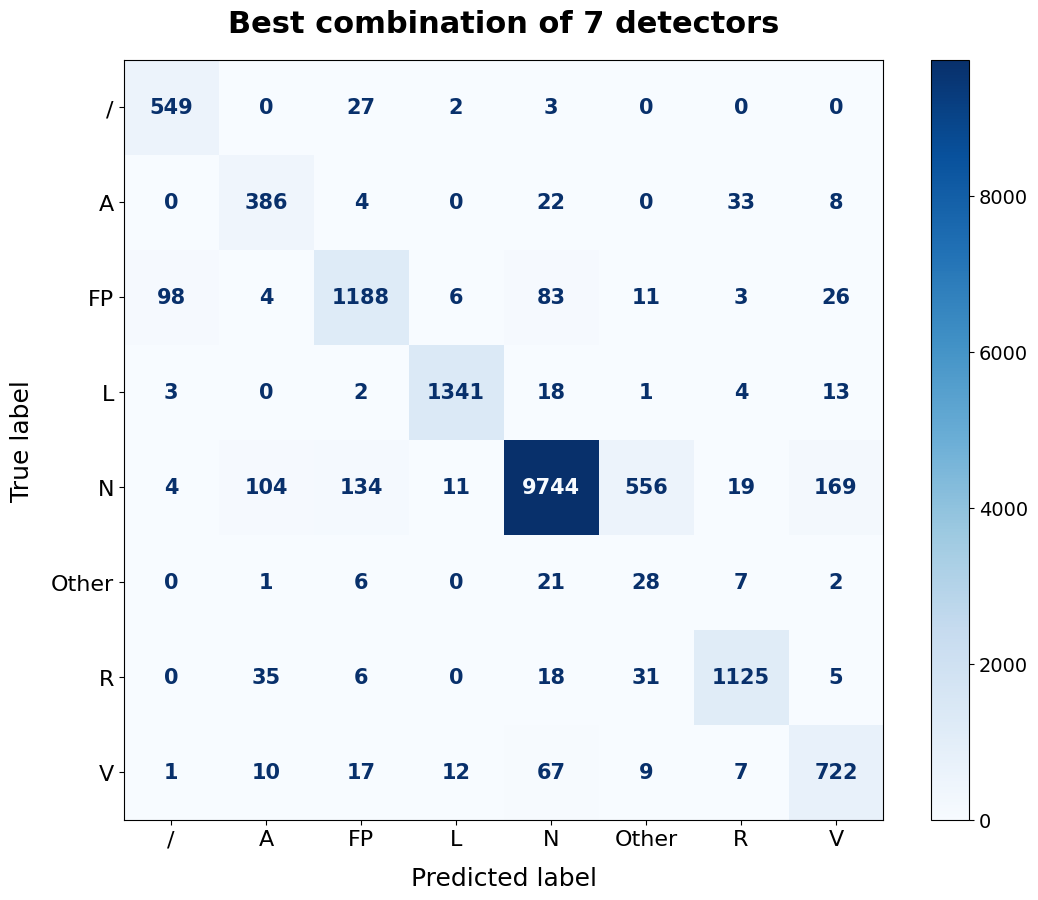

,metric,value
0,accuracy,0.9028
1,balanced_accuracy,0.8399
2,mean_sensitivity,0.8399
3,mean_specificity,0.9844


,class,sensitivity,specificity
0,/,0.9449,0.9934
1,A,0.8521,0.9905
2,FP,0.8372,0.9872
3,L,0.9703,0.9980
4,N,0.9072,0.9611
5,Other,0.4308,0.9635
6,R,0.9221,0.9953
7,V,0.8544,0.9859


In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    multilabel_confusion_matrix,
)


classes = classifier.classes_


# Overall metrics
accuracy = accuracy_score(
    y_test,
    test_predictions,
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions,
)


# Sensitivity = recall for each class
sensitivities = recall_score(
    y_test,
    test_predictions,
    labels=classes,
    average=None,
    zero_division=0,
)


# One-vs-rest confusion matrix for each class
class_confusion_matrices = multilabel_confusion_matrix(
    y_test,
    test_predictions,
    labels=classes,
)

specificities = []

for class_matrix in class_confusion_matrices:
    tn, fp, fn, tp = class_matrix.ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    specificities.append(specificity)


specificities = np.asarray(
    specificities,
    dtype=float,
)


# Mean class-wise metrics
mean_sensitivity = np.mean(
    sensitivities,
)

mean_specificity = np.mean(
    specificities,
)


# Plot
fig, ax = plt.subplots(
    figsize=(11, 9),
)

display_object = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=classes,
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True,
)


# Numbers inside confusion-matrix cells
for text in display_object.text_.ravel():
    text.set_fontsize(15)
    text.set_fontweight("bold")


# Title
ax.set_title(
    "Best combination of 7 detectors",
    # "5 detectors from literature",
    # "All 41 detectors",
    fontsize=22,
    fontweight="bold",
    pad=20,
)


# Axis descriptions
ax.set_xlabel(
    "Predicted label",
    fontsize=18,
    labelpad=12,
)

ax.set_ylabel(
    "True label",
    fontsize=18,
    labelpad=12,
)


# Class names on both axes
ax.tick_params(
    axis="both",
    labelsize=16,
)


# Colorbar numbers
if display_object.im_.colorbar is not None:
    display_object.im_.colorbar.ax.tick_params(
        labelsize=14,
    )


plt.tight_layout()
plt.show()


# Per-class metrics table
metrics_df = pd.DataFrame(
    {
        "class": classes,
        "sensitivity": sensitivities,
        "specificity": specificities,
    }
)


# Overall metrics table
overall_metrics_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "balanced_accuracy",
            "mean_sensitivity",
            "mean_specificity",
        ],
        "value": [
            accuracy,
            balanced_accuracy,
            mean_sensitivity,
            mean_specificity,
        ],
    }
)


display(
    overall_metrics_df.style.format(
        {"value": "{:.4f}"}
    )
)

display(
    metrics_df.style.format(
        {
            "sensitivity": "{:.4f}",
            "specificity": "{:.4f}",
        }
    )
)

In [72]:
metrics_df

,class,sensitivity,specificity
0,/,0.944923,0.993426
1,A,0.852097,0.990525
2,FP,0.837209,0.987179
3,L,0.970333,0.997977
4,N,0.907178,0.961106
5,Other,0.430769,0.963464
6,R,0.922131,0.995286
7,V,0.854438,0.985940


In [74]:
from sklearn.metrics import f1_score


# Per-class F1
f1_scores = f1_score(
    y_test,
    test_predictions,
    labels=classes,
    average=None,
    zero_division=0,
)


metrics_df = pd.DataFrame(
    {
        "class": classes,
        "sensitivity": sensitivities,
        "specificity": specificities,
        "F1": f1_scores,
    }
)


# Mean across all classes
mean_all = metrics_df[
    ["sensitivity", "specificity", "F1"]
].mean()


# Mean excluding FP and Other
metrics_without_fp_other = metrics_df.loc[
    ~metrics_df["class"].isin(["FP", "Other"])
]

mean_without_fp_other = metrics_without_fp_other[
    ["sensitivity", "specificity", "F1"]
].mean()


summary_df = pd.DataFrame(
    {
        "all_classes": mean_all,
        "excluding_FP_and_Other": mean_without_fp_other,
    }
).T


display(metrics_df)

display(
    (summary_df * 100).style.format("{:.2f}%")
)

,class,sensitivity,specificity,F1
0,/,0.944923,0.993426,0.888350
1,A,0.852097,0.990525,0.777442
2,FP,0.837209,0.987179,0.847663
3,L,0.970333,0.997977,0.973856
4,N,0.907178,0.961106,0.940677
5,Other,0.430769,0.963464,0.079886
6,R,0.922131,0.995286,0.930521
7,V,0.854438,0.985940,0.806704


,sensitivity,specificity,F1
all_classes,83.99%,98.44%,78.06%
excluding_FP_and_Other,90.85%,98.74%,88.63%


## Tree and feature importance

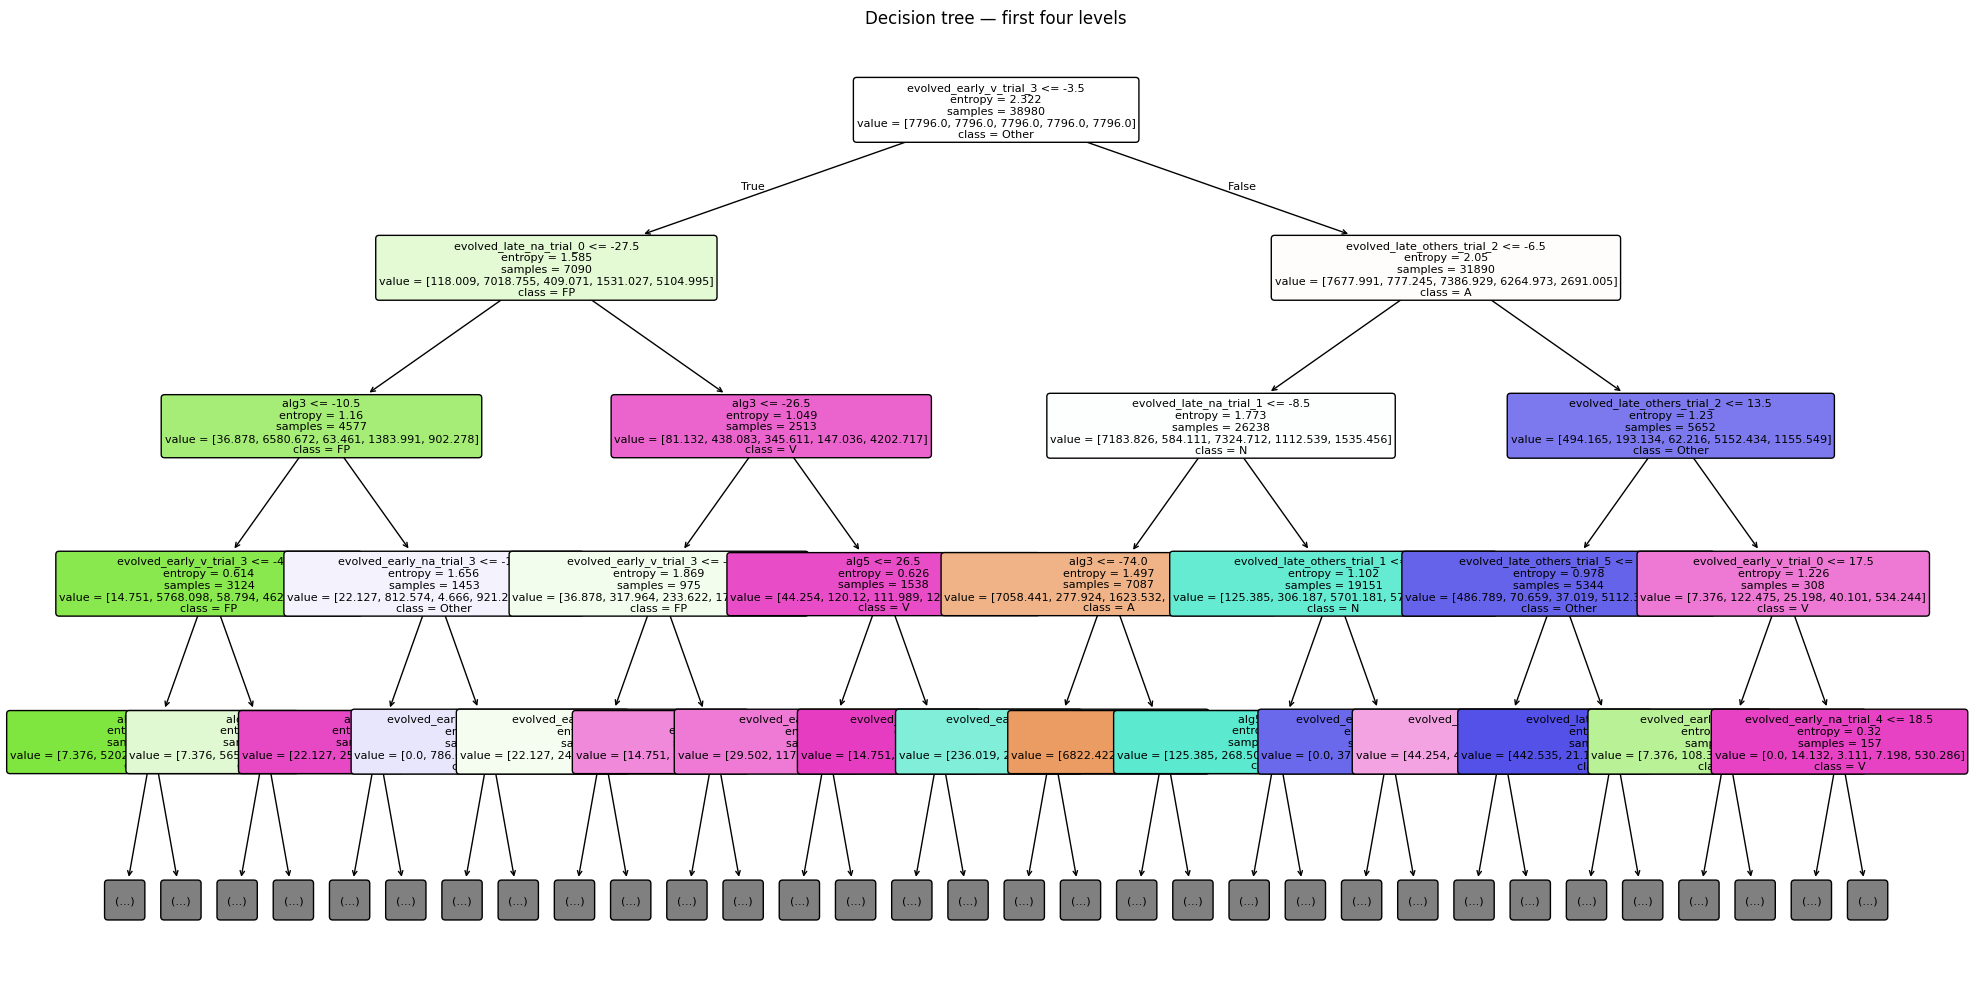

,importance
evolved_early_v_trial_3,0.214219
evolved_late_others_trial_2,0.145071
alg3,0.095036
evolved_late_na_trial_1,0.087403
alg5,0.085918
evolved_late_na_trial_0,0.079995
evolved_late_others_trial_5,0.026533
evolved_early_na_trial_3,0.026211
evolved_late_others_trial_1,0.022436
evolved_early_v_trial_2,0.020569


In [164]:
fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    classifier,
    feature_names=SELECTED_FEATURES,
    class_names=[str(label) for label in classifier.classes_],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    ax=ax,
)

ax.set_title("Decision tree — first four levels")
plt.tight_layout()
plt.show()

feature_importance = (
    pd.Series(
        classifier.feature_importances_,
        index=SELECTED_FEATURES,
        name="importance",
    )
    .sort_values(ascending=False)
    .to_frame()
)

display(feature_importance)